# Pipeline for sales data

## Understanding Data

In [40]:
import pandas as pd

In [41]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [42]:
df.shape

(2640, 12)

In [43]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.sample(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1086,2016,11,Europe,Model X,10075,11169,58439.09,100,595,899.19,Interpolated (Month),3797
1840,2018,1,Middle East,Model Y,14636,16424,92828.17,60,341,748.63,Official (Quarter),6064
517,2018,6,Middle East,Model Y,8352,9537,108951.58,120,677,848.15,Interpolated (Month),3926
2050,2021,10,Asia,Model Y,9281,9926,82922.68,100,593,825.54,Interpolated (Month),12153
753,2023,3,Asia,Model 3,13511,14683,98246.08,60,333,674.87,Interpolated (Month),12853


In [47]:
df.corr(numeric_only=True)['Estimated_Deliveries']

Year                   -0.002863
Month                   0.030877
Estimated_Deliveries    1.000000
Production_Units        0.994234
Avg_Price_USD          -0.027546
Battery_Capacity_kWh   -0.007765
Range_km               -0.006606
CO2_Saved_tons          0.836814
Charging_Stations       0.000753
Name: Estimated_Deliveries, dtype: float64

## Data Preprocessing

In [48]:
df_copy = df.copy()

In [49]:
print(df_copy['Region'].unique())
print(df_copy['Source_Type'].unique())

['Europe' 'Asia' 'North America' 'Middle East']
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [50]:
kwargs = {'year':df['Year'], 'month':df['Month'], 'day':1}
df_copy['Date'] = pd.to_datetime(kwargs)
df_copy.drop(columns=['Year', 'Month'], inplace=True)

In [51]:
df_copy.head()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


## EDA

<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

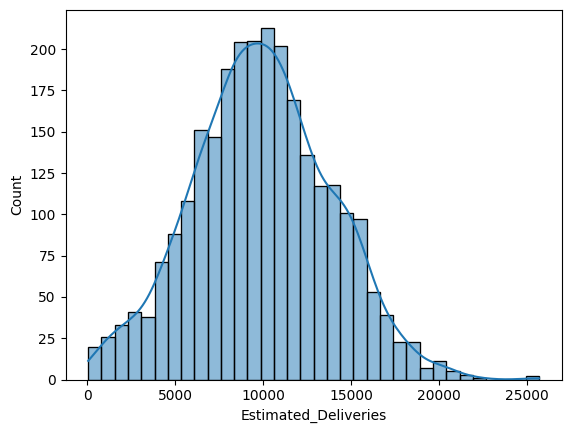

In [52]:
import seaborn as sns
sns.histplot(df["Estimated_Deliveries"], kde=True)

<Axes: ylabel='Estimated_Deliveries'>

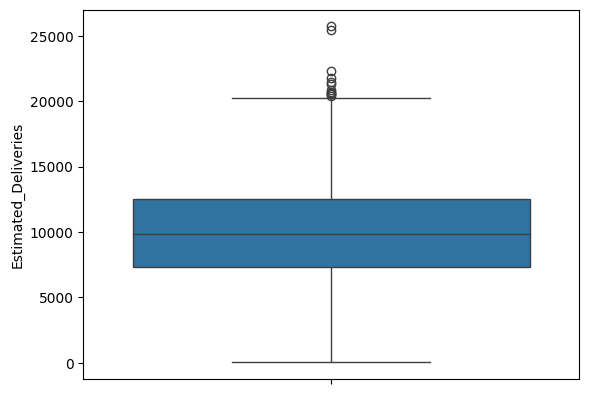

In [53]:
sns.boxplot(df_copy['Estimated_Deliveries'])

<Axes: xlabel='Model', ylabel='Estimated_Deliveries'>

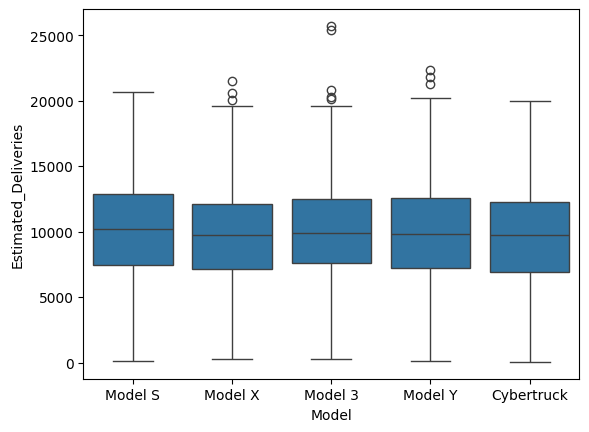

In [54]:
sns.boxplot(
    x="Model",
    y="Estimated_Deliveries",
    data=df_copy
)

<Axes: >

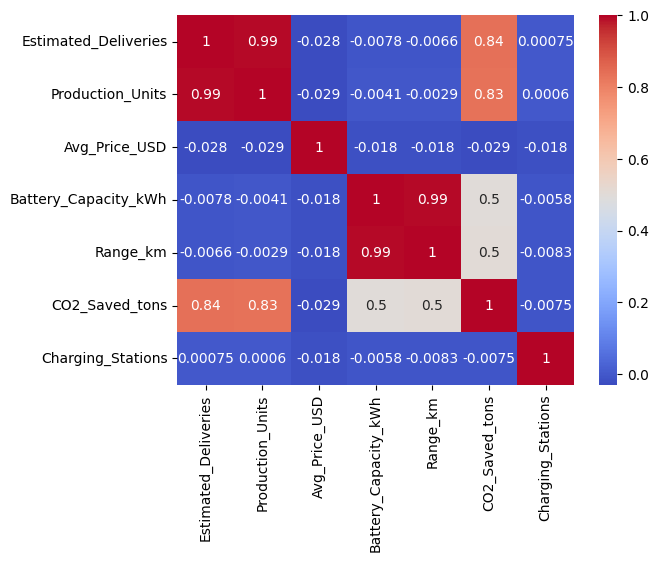

In [55]:
corr = df_copy.select_dtypes("number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='Date', ylabel='Deliveries'>

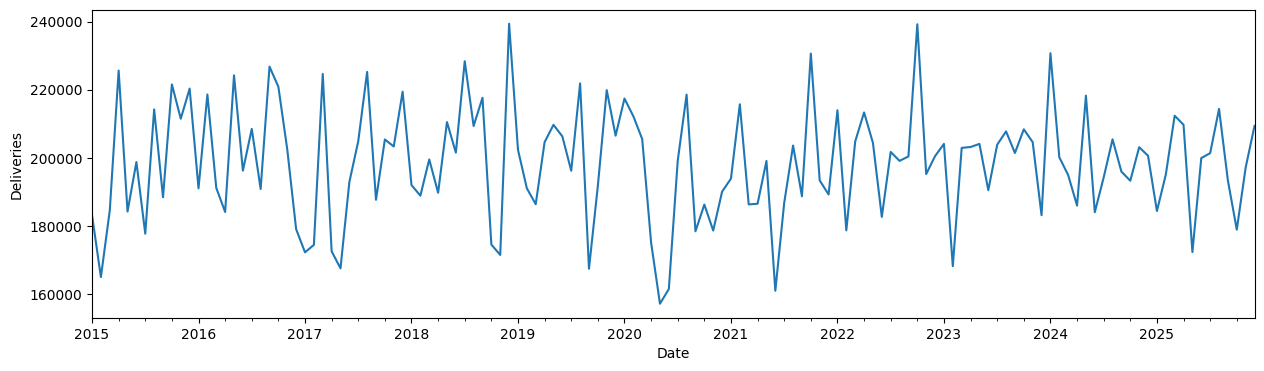

In [56]:
monthly_deliveries = df_copy.groupby("Date")["Estimated_Deliveries"].sum()
monthly_deliveries.plot(figsize=(15,4), ylabel='Deliveries')

## Feature Engg.

In [57]:
df_copy = df_copy.sort_values("Date")

df_copy["lag_1"] = df_copy["Estimated_Deliveries"].shift(1)
df_copy["lag_3"] = df_copy["Estimated_Deliveries"].shift(3)
df_copy["lag_6"] = df_copy["Estimated_Deliveries"].shift(6)

In [58]:
df_copy.head()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,lag_1,lag_3,lag_6
872,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,NaN,NaN,NaN
2354,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,12446.0,NaN,NaN
2312,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,NaN,NaN
2293,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,12446.0,NaN
2215,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,11446.0,NaN


In [59]:
df_copy.columns

Index(['Region', 'Model', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Source_Type', 'Charging_Stations', 'Date', 'lag_1', 'lag_3', 'lag_6'],
      dtype='object')

In [60]:
df_copy["Year"] = df_copy["Date"].dt.year
df_copy["Month"] = df_copy["Date"].dt.month
# df_copy["Quarter"] = df_copy["Date"].dt.quarter

In [61]:
df_copy = df_copy.dropna().reset_index(drop=True)

## Model Training

In [62]:
# X = pd.get_dummies(
#     X,
#     columns=[
#         "Region",
#         "Model",
#         "Source_Type"
#     ],
#     drop_first=True
# )

In [63]:
X = df_copy.drop(columns=["Estimated_Deliveries", "CO2_Saved_tons", "Date"])
y = df_copy["Estimated_Deliveries"]

In [64]:
split_ind = int(len(X) * 0.8)
X_train = X.iloc[:split_ind]
X_test = X.iloc[split_ind:]

y_train = y.iloc[:split_ind]
y_test = y.iloc[split_ind:]

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [67]:
categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]

numerical_features = [
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "Charging_Stations",
    "Year",
    "Month",
    "lag_1",
    "lag_3",
    "lag_6"
]

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "Numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "Catagorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [70]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [71]:
X_train.head()

,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,Source_Type,Charging_Stations,lag_1,lag_3,lag_6,Year,Month
0,North America,Model S,13302,91906.09,82,457,Estimated (Region),4871,2161.0,6367.0,12446.0,2015,1
1,Europe,Model X,8878,113652.43,82,461,Official (Quarter),10950,11986.0,8795.0,11446.0,2015,1
2,North America,Model 3,9528,110632.33,75,435,Estimated (Region),11496,8833.0,2161.0,8803.0,2015,1
3,Europe,Model S,4736,53251.53,82,475,Interpolated (Month),5046,9446.0,11986.0,6367.0,2015,1
4,North America,Model X,8343,62838.32,75,423,Official (Quarter),9297,4350.0,8833.0,8795.0,2015,1


In [72]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical', ...), ('Catagorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

print("MAE:",mean_absolute_error(y_test, y_pred))
print("RMSE:",root_mean_squared_error(y_test,y_pred))
print("R²:",r2_score(y_test, y_pred))

MAE: 354.1581270926192
RMSE: 428.14981671397254
R²: 0.986236629333197


In [88]:
import pickle

with open ("tesla_sales_pipeline.pkl", 'wb') as file:
    pickle.dump(pipeline, file)